In [2]:
# Connect Google Colab ke BigQuery
from google.colab import auth
auth.authenticate_user()
from google.cloud import bigquery
import pandas as pd
client = bigquery.Client(project="portof-510606")

In [3]:
# Load data dari BigQuery
query = """
SELECT *
FROM `portof-510606.ecommerce.sales_profit_analysis`
"""
df = client.query(query).to_dataframe()
df = df.drop_duplicates(subset="order_item_id").copy()
df.head()

,order_id,order_date,customer_id,order_item_id,product_id,product_name,category,quantity,sales,profit
0,ORD1097775,2025-10-25,CUST112905,OI10248650,PROD10000,Sen Basic Staple,Grocery,4,616.0,-79.52
1,ORD1080532,2025-10-29,CUST119205,OI10204925,PROD10000,Sen Basic Staple,Grocery,3,442.2,-79.44
2,ORD1059320,2025-10-23,CUST118214,OI10150929,PROD10000,Sen Basic Staple,Grocery,3,462.0,-59.64
3,ORD1060839,2025-12-30,CUST118788,OI10154723,PROD10000,Sen Basic Staple,Grocery,3,462.0,-59.64
4,ORD1086214,2025-12-31,CUST106288,OI10219241,PROD10000,Sen Basic Staple,Grocery,5,825.0,-44.40


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118254 entries, 0 to 118253
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       118254 non-null  object 
 1   order_date     118254 non-null  dbdate 
 2   customer_id    118254 non-null  object 
 3   order_item_id  118254 non-null  object 
 4   product_id     118254 non-null  object 
 5   product_name   118254 non-null  object 
 6   category       118254 non-null  object 
 7   quantity       118254 non-null  Int64  
 8   sales          118254 non-null  float64
 9   profit         118254 non-null  float64
dtypes: Int64(1), dbdate(1), float64(2), object(6)
memory usage: 9.1+ MB


,quantity,sales,profit
count,118254.0,118254.000000,118254.000000
mean,2.298096,9635.535401,790.147077
std,1.13803,25912.951082,3627.424830
min,1.0,33.500000,-72166.240000
25%,1.0,880.000000,62.500000
50%,2.0,2231.000000,315.080000
75%,3.0,6205.500000,980.940000
max,8.0,528400.000000,75057.360000


In [5]:
# Business metrics
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
units_sold = df["quantity"].sum()
profit_margin = (total_profit / total_sales) * 100
print(f"Total Sales   : {total_sales:,.2f}")
print(f"Total Profit  : {total_profit:,.2f}")
print(f"Units Sold    : {units_sold:,.0f}")
print(f"Profit Margin : {profit_margin:.2f}%")

Total Sales   : 1,139,440,603.30
Total Profit  : 93,438,052.45
Units Sold    : 271,759
Profit Margin : 8.20%


In [6]:
# Sales dan profit per kategori
category_analysis = (
    df.groupby("category")
      .agg(
          units_sold=("quantity", "sum"),
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum")
      )
      .sort_values("total_sales", ascending=False)
)
category_analysis

,units_sold,total_sales,total_profit
category,,,
Electronics,27317,5.673335e+08,5695162.46
Appliances,16633,1.910661e+08,7533207.41
Home & Kitchen,28045,7.345426e+07,13188151.69
Furniture,3729,6.890300e+07,6842671.37
Fashion,45732,6.466397e+07,21463793.68
Footwear,14863,3.773154e+07,11101917.42
Bags,13745,2.557954e+07,7275742.69
Health & Wellness,16614,1.466874e+07,3220619.88
Sports,6210,1.230690e+07,2739759.94


In [7]:
# Sales dan profit per produk
product_analysis = (
    df.groupby(["product_id", "product_name", "category"])
      .agg(
          units_sold=("quantity", "sum"),
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum")
      )
      .sort_values("total_sales", ascending=False)
)
product_analysis.head(10)

,,,units_sold,total_sales,total_profit
product_id,product_name,category,,,
PROD10246,"Chaudhry, Advanced Smartwatche",Electronics,4195,2.429540e+08,5232479.90
PROD10203,"Mistry, Basic Large Appliance",Appliances,4556,4.936099e+07,592702.66
PROD10392,Gandhi-Lanka Ultra Storage & Container,Home & Kitchen,5057,3.722861e+07,7695627.01
PROD10445,Kala-Vaidya Deluxe Laptop,Electronics,642,3.350097e+07,-1406862.34
PROD10435,"Boase, Ultra Air Conditioner",Appliances,730,3.040975e+07,2361066.10
PROD10301,"Choudhury, Ultra Laptop",Electronics,1017,2.824453e+07,-31812.51
PROD10236,Shanker-Dhar Signature Headphone,Electronics,4055,2.642392e+07,1474799.40
PROD10432,Gola Essential Fans & Cooler,Appliances,484,2.462806e+07,-258736.06
PROD10306,Handa Advanced Laptop,Electronics,361,2.409910e+07,-800860.36


In [8]:
# Products most profitable
product_analysis.sort_values(
    "total_profit",
    ascending=False
).head(10)

,,,units_sold,total_sales,total_profit
product_id,product_name,category,,,
PROD10392,Gandhi-Lanka Ultra Storage & Container,Home & Kitchen,5057,3.722861e+07,7695627.01
PROD10231,Setty Essential Formal Shoe,Footwear,3912,1.861436e+07,5966781.06
PROD10246,"Chaudhry, Advanced Smartwatche",Electronics,4195,2.429540e+08,5232479.90
PROD10403,Chanda Deluxe Winter Wear,Fashion,8415,1.487032e+07,4832906.40
PROD10031,Shah Basic Handbag,Bags,5127,1.400997e+07,4040571.27
PROD10051,Ramakrishnan Advanced Winter Wear,Fashion,2367,9.678753e+06,3469922.64
PROD10488,Kar-Issac Premium Kids Wear,Fashion,4686,8.179567e+06,2589824.69
PROD10435,"Boase, Ultra Air Conditioner",Appliances,730,3.040975e+07,2361066.10
PROD10341,"Solanki, Basic Winter Wear",Fashion,6505,6.839398e+06,2158855.30


In [9]:
# Monthly sales and profit
df["order_date"] = pd.to_datetime(df["order_date"])
monthly_analysis = (
    df.groupby(df["order_date"].dt.to_period("M"))
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          units_sold=("quantity", "sum")
      )
      .reset_index()
)
monthly_analysis["order_date"] = monthly_analysis["order_date"].astype(str)
monthly_analysis

,order_date,total_sales,total_profit,units_sold
0,2024-12,2.620047e+06,65987.42,560
1,2025-01,6.417360e+07,5230593.73,14955
2,2025-02,5.162278e+07,4635020.18,12540
3,2025-03,7.037031e+07,5839452.15,16930
4,2025-04,6.221194e+07,5692392.05,15008
5,2025-05,6.150059e+07,5321613.78,15046
6,2025-06,6.619533e+07,5680243.26,15570
7,2025-07,7.068546e+07,5637845.03,17243
8,2025-08,8.031480e+07,7262195.08,19572
9,2025-09,8.277396e+07,7277427.84,19891


In [10]:
# bulan dengan sales tertinggi
monthly_analysis.sort_values(
    "total_sales",
    ascending=False
).head(5)

,order_date,total_sales,total_profit,units_sold
12,2025-12,2.359423e+08,18645976.06,55776
11,2025-11,1.536930e+08,12618472.77,35720
10,2025-10,1.373364e+08,9530833.10,32948
9,2025-09,8.277396e+07,7277427.84,19891
8,2025-08,8.031480e+07,7262195.08,19572


In [11]:
# profit tertinggi
monthly_analysis.sort_values(
    "total_profit",
    ascending=False
).head(5)

,order_date,total_sales,total_profit,units_sold
12,2025-12,2.359423e+08,18645976.06,55776
11,2025-11,1.536930e+08,12618472.77,35720
10,2025-10,1.373364e+08,9530833.10,32948
9,2025-09,8.277396e+07,7277427.84,19891
8,2025-08,8.031480e+07,7262195.08,19572


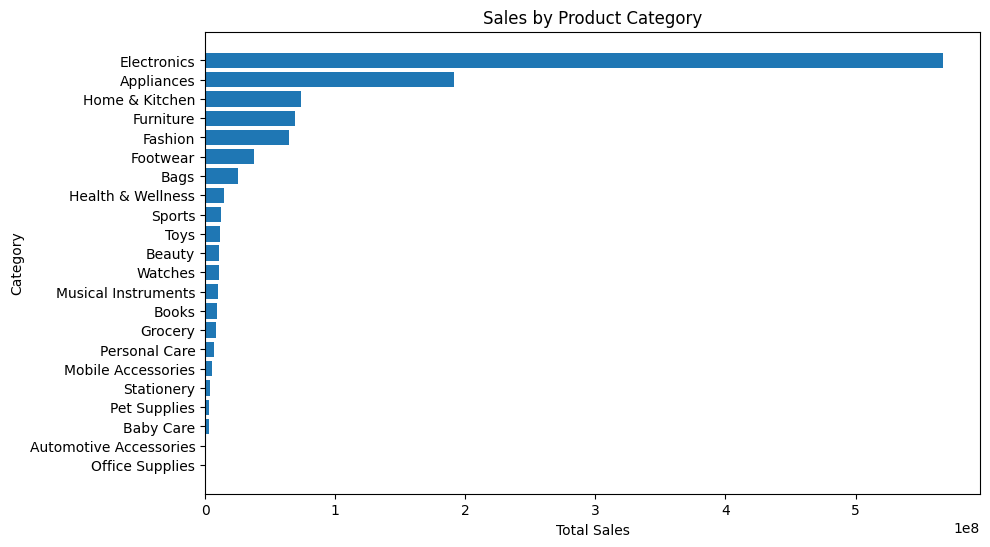

In [12]:
import matplotlib.pyplot as plt

category_plot = category_analysis.sort_values(
    "total_sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_plot.index,
    category_plot["total_sales"]
)

plt.title("Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.show()

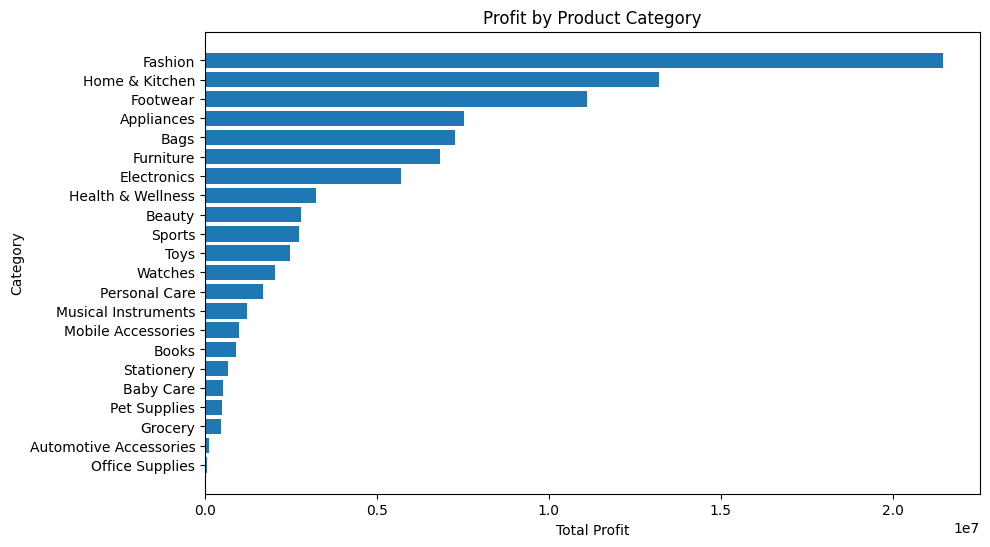

In [13]:
category_plot = category_analysis.sort_values(
    "total_profit",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_plot.index,
    category_plot["total_profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")

plt.show()